In [1]:
# Install HuggingFace Transformers and related libraries
!pip install transformers datasets scikit-learn torch --quiet
print("✅ Libraries installed successfully.")

✅ Libraries installed successfully.


In [2]:
from google.colab import files
import pandas as pd

df = pd.read_csv('textdataset/combined_cleaned.csv')

print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n📋 First 5 rows:")
df.head()

✅ Dataset loaded: 6688 rows, 4 columns

📋 First 5 rows:


,text,label,word_count,length_bucket
0,Driverless cars would Ge a good idea. It would...,0,187,0
1,"Dear Principal, All students go to school to g...",0,198,0
2,Some people believe in different things such a...,0,201,0
3,Have you ever wanted to help animals cross the...,0,163,0
4,Even though different technology can do many t...,0,195,0


In [4]:
# ─── CONFIGURE COLUMN NAMES HERE ───────────────────────────────────────────
TEXT_COLUMN  = 'text'   # Column containing the text
LABEL_COLUMN = 'label'  # Column containing labels (0 = Human, 1 = AI)
# ───────────────────────────────────────────────────────────────────────

In [ ]:


print("📊 Column names in your dataset:", df.columns.tolist())
print("\n📊 Label distribution:")
print(df[LABEL_COLUMN].value_counts())
print("\n📊 Missing values:")
print(df[[TEXT_COLUMN, LABEL_COLUMN]].isnull().sum())

# Drop rows with missing text or labels
df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna().reset_index(drop=True)
print(f"\n✅ Clean dataset size: {len(df)} samples")

📊 Column names in your dataset: ['text', 'label', 'word_count']

📊 Label distribution:
label
1    210240
0    208038
Name: count, dtype: int64

📊 Missing values:
text     0
label    0
dtype: int64

✅ Clean dataset size: 418278 samples


In [ ]:
# ── Balance by length across both classes ────────────────────────────────────
df['text_length'] = df[TEXT_COLUMN].apply(lambda x: len(str(x).split()))

# Remove extremely short texts (under 10 words) — too ambiguous to learn from
df = df[df['text_length'] >= 10].reset_index(drop=True)
print(f"✅ After removing short texts: {len(df)} samples")

# Balance class sizes
min_class_size = df[LABEL_COLUMN].value_counts().min()
df = (df.groupby(LABEL_COLUMN, group_keys=False)
        .apply(lambda x: x.sample(min_class_size, random_state=42))
        .reset_index(drop=True))

print(f"✅ Balanced dataset: {len(df)} samples")
print(df[LABEL_COLUMN].value_counts())

# Balance by length too — match length distributions across classes
df['length_bucket'] = pd.cut(df['text_length'], bins=10, labels=False)
df = (df.groupby([LABEL_COLUMN, 'length_bucket'], group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 500), random_state=42))
        .reset_index(drop=True))

print(f"✅ Length-balanced dataset: {len(df)} samples")

✅ After removing short texts: 418278 samples


/tmp/ipykernel_6835/1134211454.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_class_size, random_state=42))


✅ Balanced dataset: 416076 samples
label
0    208038
1    208038
Name: count, dtype: int64
✅ Length-balanced dataset: 6688 samples


/tmp/ipykernel_6835/1134211454.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 500), random_state=42))


In [5]:
# Add short casual human text examples to training data
extra_human = pd.DataFrame({
    TEXT_COLUMN: [
        "I wrote this myself and I think it looks good",
        "My name is Rumesa. I am 20 years old",
        "The quick brown fox jumps over the lazy dog",
        "Just got home from work. Really tired today",
        "Hey what time are we meeting tomorrow?",
        "I don't know man, seems weird to me",
        "lol that was so funny i cant stop laughing",
        "ok so basically what happened was crazy",
        "gonna grab coffee before the meeting starts",
        "not sure if i should go or just stay home",
        "This is my homework. I did it last night.",
        "We went to the park and it was really fun",
        "I think cats are better than dogs tbh",
        "The movie was okay but kind of boring",
        "Can you help me with this? I'm confused",
    ] * 20,   # repeat to give it enough weight
    LABEL_COLUMN: [0] * 300    # 0 = Human
})

df = pd.concat([df, extra_human], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
print(f"✅ Added short human samples. New size: {len(df)}")
print(df[LABEL_COLUMN].value_counts())

✅ Added short human samples. New size: 6988
label
0    4148
1    2840
Name: count, dtype: int64


In [6]:
import re

def preprocess_text(text):
    """
    Step 2: Text Preprocessing
    - Lowercase
    - Remove URLs, special characters, extra whitespace
    - Strip leading/trailing spaces
    Note: Tokenization & padding are handled by the BERT tokenizer in Cell 6.
    """
    text = str(text).lower()                          # Lowercasing
    text = re.sub(r'http\S+|www\S+', '', text)        # Remove URLs
    text = re.sub(r'[^a-z0-9\s.,!?\'\"\-]', '', text) # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()          # Remove extra spaces
    return text

df['clean_text'] = df[TEXT_COLUMN].apply(preprocess_text)

print("✅ Text preprocessing complete.")
print("\n🔎 Sample before/after:")
print("ORIGINAL:", df[TEXT_COLUMN][0][:200])
print("CLEANED: ", df['clean_text'][0][:200])

✅ Text preprocessing complete.

🔎 Sample before/after:
ORIGINAL: Importance of Keeping the Electoral College Dear Senator [Senator's Last Name], I hope this letter finds you well. I am writing to discuss a crucial issue that has been the subject of much debate and 
CLEANED:  importance of keeping the electoral college dear senator senator's last name, i hope this letter finds you well. i am writing to discuss a crucial issue that has been the subject of much debate and di


In [7]:
from sklearn.model_selection import train_test_split

# Encode labels to integers (if they are strings like 'human'/'ai')
label_map = {}
unique_labels = df[LABEL_COLUMN].unique()
if df[LABEL_COLUMN].dtype == object:
    label_map = {lbl: idx for idx, lbl in enumerate(sorted(unique_labels))}
    df['encoded_label'] = df[LABEL_COLUMN].map(label_map)
    print(f"📌 Label mapping: {label_map}")
else:
    df['encoded_label'] = df[LABEL_COLUMN]
    label_map = {0: 'Human Written', 1: 'AI Generated'}
    print(f"📌 Labels are already integers. Assumed: 0=Human, 1=AI")

# 80% train | 10% validation | 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    df['clean_text'], df['encoded_label'], test_size=0.2,
    stratify=df['encoded_label'], random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,
    stratify=y_temp, random_state=42
)

print(f"\n✅ Split complete:")
print(f"   Train : {len(X_train)} samples")
print(f"   Val   : {len(X_val)} samples")
print(f"   Test  : {len(X_test)} samples")

📌 Labels are already integers. Assumed: 0=Human, 1=AI

✅ Split complete:
   Train : 5590 samples
   Val   : 699 samples
   Test  : 699 samples


In [8]:
import gc
import torch
import pandas as pd

# 1. Free anything leftover from previous runs
gc.collect()
torch.cuda.empty_cache()

# 2. Drop full dataframe — you only need X_train/X_val/X_test splits now
del df
gc.collect()

# 3. Check available RAM
import psutil
ram = psutil.virtual_memory()
print(f"RAM — Total: {ram.total/1e9:.1f}GB | Used: {ram.used/1e9:.1f}GB | Free: {ram.available/1e9:.1f}GB")
print(f"GPU — Allocated: {torch.cuda.memory_allocated()/1e9:.2f}GB | Free: {torch.cuda.memory_reserved()/1e9:.2f}GB")

RAM — Total: 13.6GB | Used: 3.0GB | Free: 10.2GB
GPU — Allocated: 0.00GB | Free: 0.00GB


In [9]:
from transformers import DistilBertTokenizerFast
import torch
from torch.utils.data import Dataset, DataLoader

MODEL_NAME  = 'distilbert-base-uncased'
MAX_LENGTH  = 128
BATCH_SIZE  = 32

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)    # just strings — tiny memory footprint
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # ✅ Tokenize ONE sample at a time, on demand
        encoding = tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = TextDataset(X_train, y_train)
val_dataset   = TextDataset(X_val,   y_val)
test_dataset  = TextDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE * 2,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE * 2,
                          num_workers=2, pin_memory=True)

print(f"✅ Dataset ready | Samples: {len(train_dataset)} train / {len(val_dataset)} val / {len(test_dataset)} test")
print(f"   Tokenization is lazy (per batch) — RAM usage is minimal")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Dataset ready | Samples: 5590 train / 699 val / 699 test
   Tokenization is lazy (per batch) — RAM usage is minimal


In [10]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch.cuda.amp import GradScaler   # Mixed precision
from torch.nn import CrossEntropyLoss



# Label smoothing — prevents 99% confidence predictions


NUM_CLASSES = 2
EPOCHS      = 10          # ⬇ reduced from 4 — DistilBERT converges fast
LR          = 3e-5       # ⬆ slightly higher LR = faster convergence
ACCUM_STEPS = 2          # Gradient accumulation (simulates larger batch without OOM)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES
)
model = model.to(device)

loss_fn = CrossEntropyLoss(label_smoothing=0.1)
print("✅ Label smoothing applied — model will be less overconfident")

# Compile model (PyTorch 2.0+) — significant speedup on Colab T4
try:
    model = torch.compile(model)
    print("✅ torch.compile() applied")
except Exception:
    print("⚠️  torch.compile() not available — continuing without it")

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scaler    = GradScaler()   # For mixed precision (FP16)

total_steps  = (len(train_loader) // ACCUM_STEPS) * EPOCHS
warmup_steps = int(0.06 * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer,
                   num_warmup_steps=warmup_steps,
                   num_training_steps=total_steps)

print(f"✅ Model ready | Epochs={EPOCHS} | LR={LR} | AccumSteps={ACCUM_STEPS}")

⚡ Device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Label smoothing applied — model will be less overconfident
✅ torch.compile() applied
✅ Model ready | Epochs=10 | LR=3e-05 | AccumSteps=2


/tmp/ipykernel_1476/1672943280.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()   # For mixed precision (FP16)


In [12]:
# Install tqdm if needed
!pip install tqdm --quiet

import time
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# ─────────────────────────────────────────────────────────────
# Training Function
# ─────────────────────────────────────────────────────────────
def train_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    scaler,
    device,
    accum_steps,
    epoch
):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f"Epoch {epoch} [Train]", leave=True)

    for step, batch in enumerate(pbar):

        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        # Mixed Precision Forward Pass
        with torch.amp.autocast('cuda'):

            # Pass labels so HuggingFace computes loss automatically
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            # Gradient accumulation scaling
            loss = outputs.loss / accum_steps

        # Backpropagation
        scaler.scale(loss).backward()

        # Gradient Accumulation Step
        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):

            scaler.unscale_(optimizer)

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()

            scheduler.step()
            optimizer.zero_grad()

        # Track loss
        total_loss += loss.item() * accum_steps

        # Predictions
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        # Progress bar update
        pbar.set_postfix({
            'loss': f"{loss.item() * accum_steps:.4f}"
        })

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy


# ─────────────────────────────────────────────────────────────
# Validation Function
# ─────────────────────────────────────────────────────────────
def eval_epoch(model, loader, device, epoch):

    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc=f"Epoch {epoch} [Val]", leave=True)

    with torch.no_grad():

        for batch in pbar:

            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

            total_loss += outputs.loss.item()

            preds = torch.argmax(
                outputs.logits,
                dim=1
            ).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f"{outputs.loss.item():.4f}"
            })

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy


# ─────────────────────────────────────────────────────────────
# Training Loop
# ─────────────────────────────────────────────────────────────
print("🚀 Starting optimized training...\n")

best_val_acc = 0

for epoch in range(1, EPOCHS + 1):

    start_time = time.time()

    # Train
    train_loss, train_acc = train_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        device=device,
        accum_steps=ACCUM_STEPS,
        epoch=epoch
    )

    # Validate
    val_loss, val_acc = eval_epoch(
        model=model,
        loader=val_loader,
        device=device,
        epoch=epoch
    )

    elapsed = time.time() - start_time

    # Epoch Summary
    print(f"\n📊 Epoch {epoch}/{EPOCHS} Summary ({elapsed:.0f}s)")
    print(f"   Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"   Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    # Save Best Model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            'best_bert_detector.pt'
        )

        print(f"   💾 Best model saved (val_acc={val_acc:.4f})")

    print()

print(f"✅ Training complete | Best Val Acc: {best_val_acc:.4f}")

🚀 Starting optimized training...



Epoch 1 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]W0510 10:16:04.539000 1476 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
Epoch 1 [Train]:  99%|█████████▉| 174/175 [01:06<00:00,  6.73it/s, loss=0.0378]/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
Epoch 1 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is dis


📊 Epoch 1/10 Summary (120s)
   Train → Loss: 0.3773 | Acc: 0.8030
   Val   → Loss: 0.0938 | Acc: 0.9728
   💾 Best model saved (val_acc=0.9728)



Epoch 2 [Val]: 100%|██████████| 11/11 [00:02<00:00,  5.44it/s, loss=0.2069]



📊 Epoch 2/10 Summary (20s)
   Train → Loss: 0.1089 | Acc: 0.9649
   Val   → Loss: 0.1910 | Acc: 0.9242



...


📊 Epoch 8/10 Summary (22s)
   Train → Loss: 0.0048 | Acc: 0.9993
   Val   → Loss: 0.1223 | Acc: 0.9771
   💾 Best model saved (val_acc=0.9771)



Epoch 9 [Val]: 100%|██████████| 11/11 [00:02<00:00,  4.99it/s, loss=0.1047]



📊 Epoch 9/10 Summary (21s)
   Train → Loss: 0.0043 | Acc: 0.9995
   Val   → Loss: 0.1381 | Acc: 0.9728



Epoch 10 [Val]: 100%|██████████| 11/11 [00:01<00:00,  5.72it/s, loss=0.0955]


📊 Epoch 10/10 Summary (21s)
   Train → Loss: 0.0042 | Acc: 0.9995
   Val   → Loss: 0.1277 | Acc: 0.9771

✅ Training complete | Best Val Acc: 0.9771


✅ Best model loaded



Testing: 100%|██████████| 11/11 [00:28<00:00,  2.58s/it]


═══════════════════════════════════════════════════════
           🧪 TEST SET RESULTS
═══════════════════════════════════════════════════════
  ✅ Test Accuracy  : 97.00%
  📊 Total Samples  : 699
  ✔️  Correct        : 678
  ❌ Wrong          : 21
═══════════════════════════════════════════════════════

📋 Classification Report:

               precision    recall  f1-score   support

Human Written     0.9900    0.9590    0.9743       415
 AI Generated     0.9428    0.9859    0.9639       284

     accuracy                         0.9700       699
    macro avg     0.9664    0.9725    0.9691       699
 weighted avg     0.9708    0.9700    0.9701       699



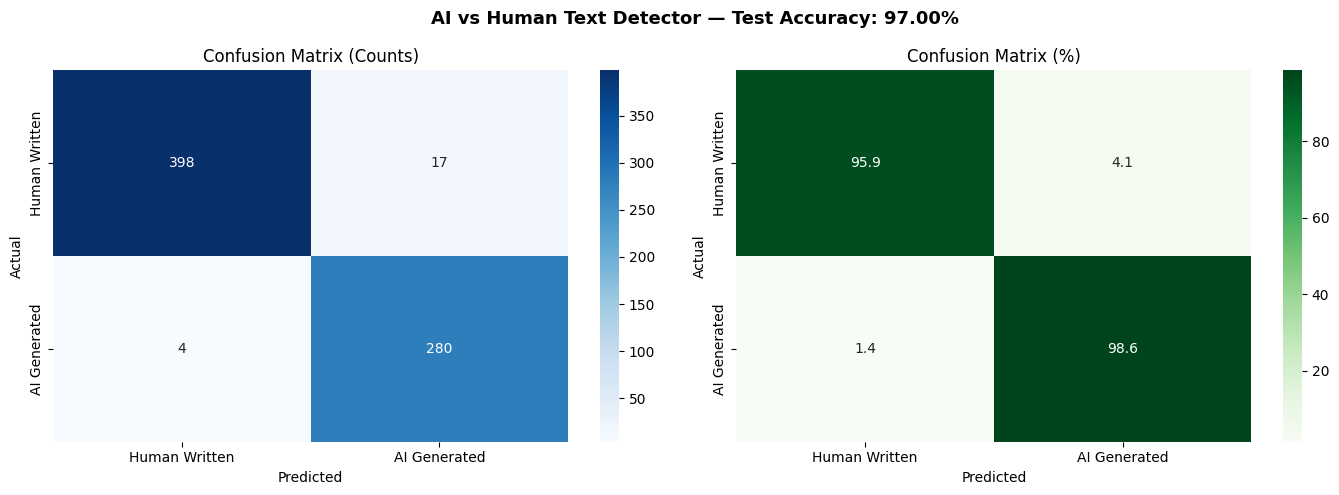

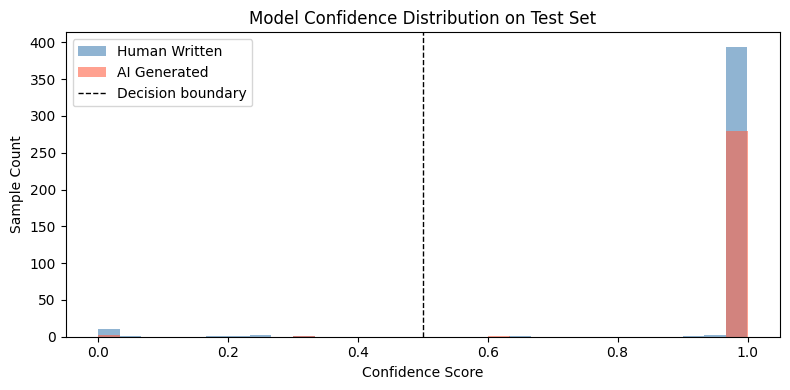


✅ Plots saved: test_results.png | confidence_distribution.png


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ── Load best saved model ─────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_bert_detector.pt', map_location=device))
model.eval()
print("✅ Best model loaded\n")

# ── Run on test set ───────────────────────────────────────────────────────────
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing", colour='yellow'):
        input_ids      = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        labels         = batch['label'].to(device, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        probs  = torch.softmax(outputs.logits, dim=1)
        preds  = torch.argmax(probs, dim=1)

        all_preds.append(preds)
        all_labels.append(labels)
        all_probs.append(probs)

# ── Move everything to CPU once ───────────────────────────────────────────────
all_preds  = torch.cat(all_preds).cpu().numpy()
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs  = torch.cat(all_probs).cpu().numpy()

# ── Print Results ─────────────────────────────────────────────────────────────
class_names = ['Human Written', 'AI Generated']
test_acc    = accuracy_score(all_labels, all_preds)

print("═" * 55)
print("           🧪 TEST SET RESULTS")
print("═" * 55)
print(f"  ✅ Test Accuracy  : {test_acc*100:.2f}%")
print(f"  📊 Total Samples  : {len(all_labels)}")
print(f"  ✔️  Correct        : {int(test_acc * len(all_labels))}")
print(f"  ❌ Wrong          : {len(all_labels) - int(test_acc * len(all_labels))}")
print("═" * 55)

print("\n📋 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Percentages
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle(f'AI vs Human Text Detector — Test Accuracy: {test_acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_results.png', dpi=150)
plt.show()

# ── Confidence Distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
human_conf = all_probs[all_labels == 0][:, 0]   # confidence for human class
ai_conf    = all_probs[all_labels == 1][:, 1]   # confidence for AI class

ax.hist(human_conf, bins=30, alpha=0.6, color='steelblue', label='Human Written')
ax.hist(ai_conf,    bins=30, alpha=0.6, color='tomato',    label='AI Generated')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision boundary')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Sample Count')
ax.set_title('Model Confidence Distribution on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150)
plt.show()

print("\n✅ Plots saved: test_results.png | confidence_distribution.png")

In [16]:
def predict_text(text, model, tokenizer, device, max_length=256):
    """
    Step 4: Text Classification
    Given raw input text, returns:
      - predicted class (Human Written / AI Generated)
      - confidence score (%)
    """
    model.eval()
    cleaned = preprocess_text(text)

    encoding = tokenizer(
        cleaned,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    predicted_class = int(np.argmax(probs))
    confidence      = float(probs[predicted_class]) * 100
    label           = class_names[predicted_class]

    return label, confidence, probs


# ─── TEST WITH YOUR OWN TEXT ────────────────────────────────────────────────
sample_texts = [
    "The quick brown fox jumps over the lazy dog. I wrote this myself!",
    "In conclusion, the utilization of advanced methodologies ensures optimal outcomes across diverse paradigms."
]

print("═" * 60)
print("         🔍 TEXT DETECTION RESULTS")
print("═" * 60)
for i, text in enumerate(sample_texts, 1):
    label, conf, probs = predict_text(text, model, tokenizer, device)
    print(f"\nSample {i}: {text[:80]}..." if len(text) > 80 else f"\nSample {i}: {text}")
    print(f"  ➤ Prediction : {label}")
    print(f"  ➤ Confidence : {conf:.2f}%")
    print(f"  ➤ Human: {probs[0]*100:.2f}% | AI: {probs[1]*100:.2f}%")
print("═" * 60)

════════════════════════════════════════════════════════════
         🔍 TEXT DETECTION RESULTS
════════════════════════════════════════════════════════════

Sample 1: The quick brown fox jumps over the lazy dog. I wrote this myself!
  ➤ Prediction : Human Written
  ➤ Confidence : 99.91%
  ➤ Human: 99.91% | AI: 0.09%

Sample 2: In conclusion, the utilization of advanced methodologies ensures optimal outcome...
  ➤ Prediction : AI Generated
  ➤ Confidence : 99.98%
  ➤ Human: 0.02% | AI: 99.98%
════════════════════════════════════════════════════════════


In [15]:
sample_texts = [
    "Hello bello my name is rumesa. How are you this is to verify is the model working correctly or not",
    "My name is Rumesa.I'm 20 year old"
]

print("═" * 60)
print("         🔍 TEXT DETECTION RESULTS")
print("═" * 60)
for i, text in enumerate(sample_texts, 1):
    label, conf, probs = predict_text(text, model, tokenizer, device)
    print(f"\nSample {i}: {text[:80]}..." if len(text) > 80 else f"\nSample {i}: {text}")
    print(f"  ➤ Prediction : {label}")
    print(f"  ➤ Confidence : {conf:.2f}%")
    print(f"  ➤ Human: {probs[0]*100:.2f}% | AI: {probs[1]*100:.2f}%")
print("═" * 60)

════════════════════════════════════════════════════════════
         🔍 TEXT DETECTION RESULTS
════════════════════════════════════════════════════════════

Sample 1: Hello bello my name is rumesa. How are you this is to verify is the model workin...
  ➤ Prediction : Human Written
  ➤ Confidence : 99.89%
  ➤ Human: 99.89% | AI: 0.11%

Sample 2: My name is Rumesa.I'm 20 year old
  ➤ Prediction : Human Written
  ➤ Confidence : 99.91%
  ➤ Human: 99.91% | AI: 0.09%
════════════════════════════════════════════════════════════


In [22]:
print("═" * 60)
print("         🔍 AI vs HUMAN TEXT DETECTOR")
print("═" * 60)

while True:

    text = input("\nEnter text (or type 'exit' to quit): ")

    # Exit condition
    if text.lower() == 'exit':
        print("\n👋 Exiting detector...")
        break

    # Skip empty input
    if text.strip() == "":
        print("⚠️ Please enter some text.")
        continue

    # Prediction
    label, conf, probs = predict_text(
        text,
        model,
        tokenizer,
        device
    )

    # Results
    print("\n📊 Detection Result")
    print("─" * 40)
    print(f"➤ Prediction : {label}")
    print(f"➤ Confidence : {conf:.2f}%")
    print(f"➤ Human      : {probs[0]*100:.2f}%")
    print(f"➤ AI         : {probs[1]*100:.2f}%")
    print("─" * 40)

════════════════════════════════════════════════════════════
         🔍 AI vs HUMAN TEXT DETECTOR
════════════════════════════════════════════════════════════

Enter text (or type 'exit' to quit): Thank you for letting me give the project evaluation online due to my health issues. I wanted to request you to kindly re evaluate my project again as you’ve given me 9/10 whereas all my group member had been given 10/10. This will affect my grade badly as I couldn’t attempt my final exam well due to my health.  Kindly consider my request. I’ll be very thankful to you.

📊 Detection Result
────────────────────────────────────────
➤ Prediction : Human Written
➤ Confidence : 99.91%
➤ Human      : 99.91%
➤ AI         : 0.09%
────────────────────────────────────────

Enter text (or type 'exit' to quit): exit

👋 Exiting detector...


✅ Best model loaded



Testing: 100%|██████████| 11/11 [00:02<00:00,  3.82it/s]


═══════════════════════════════════════════════════════
           🧪 TEST SET RESULTS
═══════════════════════════════════════════════════════
  ✅ Test Accuracy  : 97.00%
  📊 Total Samples  : 699
  ✔️  Correct        : 678
  ❌ Wrong          : 21
═══════════════════════════════════════════════════════

📋 Classification Report:

               precision    recall  f1-score   support

Human Written     0.9900    0.9590    0.9743       415
 AI Generated     0.9428    0.9859    0.9639       284

     accuracy                         0.9700       699
    macro avg     0.9664    0.9725    0.9691       699
 weighted avg     0.9708    0.9700    0.9701       699



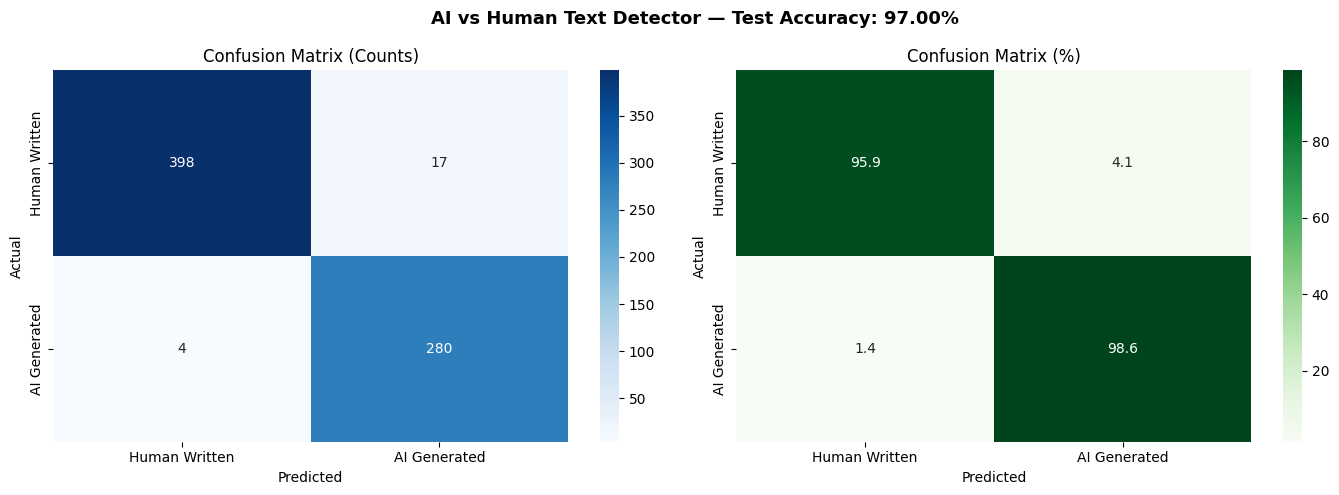

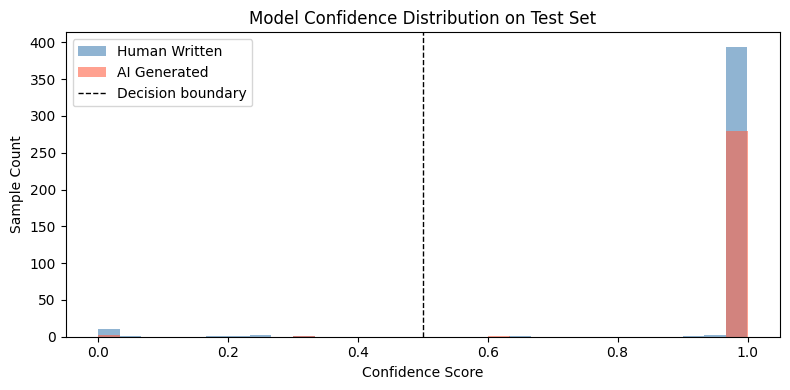


✅ Plots saved: test_results.png | confidence_distribution.png


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ── Load best saved model ─────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_bert_detector.pt', map_location=device))
model.eval()
print("✅ Best model loaded\n")

# ── Run on test set ───────────────────────────────────────────────────────────
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing", colour='yellow'):
        input_ids      = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        labels         = batch['label'].to(device, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        probs  = torch.softmax(outputs.logits, dim=1)
        preds  = torch.argmax(probs, dim=1)

        all_preds.append(preds)
        all_labels.append(labels)
        all_probs.append(probs)

# ── Move everything to CPU once ───────────────────────────────────────────────
all_preds  = torch.cat(all_preds).cpu().numpy()
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs  = torch.cat(all_probs).cpu().numpy()

# ── Print Results ─────────────────────────────────────────────────────────────
class_names = ['Human Written', 'AI Generated']
test_acc    = accuracy_score(all_labels, all_preds)

print("═" * 55)
print("           🧪 TEST SET RESULTS")
print("═" * 55)
print(f"  ✅ Test Accuracy  : {test_acc*100:.2f}%")
print(f"  📊 Total Samples  : {len(all_labels)}")
print(f"  ✔️  Correct        : {int(test_acc * len(all_labels))}")
print(f"  ❌ Wrong          : {len(all_labels) - int(test_acc * len(all_labels))}")
print("═" * 55)

print("\n📋 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Percentages
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle(f'AI vs Human Text Detector — Test Accuracy: {test_acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_results.png', dpi=150)
plt.show()

# ── Confidence Distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
human_conf = all_probs[all_labels == 0][:, 0]   # confidence for human class
ai_conf    = all_probs[all_labels == 1][:, 1]   # confidence for AI class

ax.hist(human_conf, bins=30, alpha=0.6, color='steelblue', label='Human Written')
ax.hist(ai_conf,    bins=30, alpha=0.6, color='tomato',    label='AI Generated')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision boundary')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Sample Count')
ax.set_title('Model Confidence Distribution on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150)
plt.show()

print("\n✅ Plots saved: test_results.png | confidence_distribution.png")

In [20]:
import os
from google.colab import files

# Save full model + tokenizer (for reuse)
save_dir = '/content/ai_text_detector'
os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"✅ Model and tokenizer saved to: {save_dir}")

# Zip and download
!zip -r ai_text_detector.zip /content/ai_text_detector
files.download('ai_text_detector.zip')

print("✅ Downloads started!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved to: /content/ai_text_detector
updating: content/ai_text_detector/ (stored 0%)
updating: content/ai_text_detector/tokenizer.json (deflated 71%)
updating: content/ai_text_detector/config.json (deflated 49%)
updating: content/ai_text_detector/tokenizer_config.json (deflated 42%)
updating: content/ai_text_detector/model.safetensors (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads started!
